<figure>
<center>
<img src='https://www.economicas.uba.ar/wp-content/uploads/2020/08/cropped-logo_FCE.png' />
</figure>

# 🔍 SHAP Values — Explicabilidad de Modelos

**Curso:** Ciencia de Datos  
**Tema:** Interpretabilidad · Clase Práctica

---

## ¿Qué problema resuelve SHAP?

Los modelos complejos hacen buenas predicciones pero no nos dicen *por qué*.

**SHAP (SHapley Additive exPlanations)** responde la pregunta:

> *¿Cuánto contribuyó cada variable a la predicción para **esta** observación específica?*

La idea central viene de la **Teoría de Juegos Cooperativos** (Shapley, 1953).

---

## Parte 1 — Intuición: El Reparto Justo

### Analogía: tres vendedores y una venta

Tres vendedores (A, B, C) trabajan juntos y generan distintas ganancias según cómo se combinen:

| Coalición | Ganancia |
|-----------|----------|
| {} vacía  | 0        |
| {A}       | 300      |
| {B}       | 200      |
| {C}       | 100      |
| {A,B}     | 600      |
| {A,C}     | 500      |
| {B,C}     | 400      |
| {A,B,C}   | 900      |

**Pregunta:** ¿Cómo repartir los $900 de manera justa?

La respuesta de Shapley: calcular la **contribución marginal promedio** de cada jugador en **todos los órdenes posibles** de llegada.

In [1]:
from itertools import permutations
from math import factorial

jugadores = ['A', 'B', 'C']

def ganancia(coalicion: frozenset) -> float:
    tabla = {
        frozenset():              0,
        frozenset(['A']):       300,
        frozenset(['B']):       200,
        frozenset(['C']):       100,
        frozenset(['A','B']):   600,
        frozenset(['A','C']):   500,
        frozenset(['B','C']):   400,
        frozenset(['A','B','C']): 900,
    }
    return tabla[coalicion]

def shapley_value(jugador, jugadores, funcion_valor):
    n = len(jugadores)
    total = 0
    for orden in permutations(jugadores):
        idx   = orden.index(jugador)
        antes = frozenset(orden[:idx])
        con_jugador = antes | frozenset([jugador])
        contribucion = funcion_valor(con_jugador) - funcion_valor(antes)
        total += contribucion
    return total / factorial(n)

print("=" * 40)
print("  Shapley Values — Vendedores")
print("=" * 40)
suma_total = 0
for j in jugadores:
    sv = shapley_value(j, jugadores, ganancia)
    print(f"  Vendedor {j}: ${sv:.2f}")
    suma_total += sv
print("-" * 40)
print(f"  Total repartido: ${suma_total:.2f}  (debe ser $900)")
print("=" * 40)

  Shapley Values — Vendedores
  Vendedor A: $400.00
  Vendedor B: $300.00
  Vendedor C: $200.00
----------------------------------------
  Total repartido: $900.00  (debe ser $900)


### 🧮 La fórmula de Shapley

Para cada jugador $i$:

$$\phi_i = \frac{1}{|N|!} \sum_{\text{orden}} \left[ v(S_i \cup \{i\}) - v(S_i) \right]$$

donde $S_i$ es el conjunto de jugadores que llegaron **antes** que $i$ en ese orden.

**Propiedades (axiomas de Shapley):**
1. **Eficiencia:** $\sum_i \phi_i = v(N)$ — se reparte todo
2. **Simetría:** jugadores idénticos reciben el mismo valor
3. **Jugador nulo:** si alguien no aporta nada, recibe 0
4. **Linealidad:** si combinamos dos juegos, los valores se suman

---

## Parte 2 — De Juegos a Machine Learning

| Teoría de Juegos | Machine Learning |
|-----------------|------------------|
| Jugadores | Variables (features) |
| Coalición | Subconjunto de features |
| Valor de coalición | Predicción con ese subconjunto |
| Shapley value $\phi_i$ | SHAP value de cada feature para **una observación** |

El modelo genera una predicción $\hat{y}$. SHAP la descompone:

$$\hat{y} = \underbrace{E[f(x)]}_{\text{baseline}} + \phi_1 + \phi_2 + \cdots + \phi_p$$

- El **baseline** $E[f(x)]$ es la predicción promedio sobre el dataset de entrenamiento
- Cada $\phi_j$ indica cuánto *alejó* o *acercó* la feature $j$ la predicción del baseline

---

## Parte 3 — ¿Cómo se calcula SHAP? Paso a paso

Trabajamos con una casa concreta:

| Feature | Valor observado | Media del train |
|---------|----------------|-----------------|
| `metros` | 50 | ~120 |
| `hab` | 3 | ~3 |
| `garage` | 1 | ~0.5 |

---

### Paso 1 — El modelo predice un valor

**Usamos regresión lineal porque es el modelo que los alumnos comentaron en clase que estaban viendo en otras materias (en particular este modelo puede ser explicado, de forma más simple, sin usar esta técnica)**


$$\hat{y} = \beta_0 + \beta_{\text{metros}} \cdot 50 + \beta_{\text{hab}} \cdot 3 + \beta_{\text{garage}} \cdot 1$$

---

### Paso 2 — Definir el baseline

Si no supiéramos nada de la casa, el modelo predice el promedio de todo el train:

$$E[f(x)] = \text{promedio de predicciones sobre el train set}$$

La pregunta que queremos responder es: **¿por qué la predicción de esta casa es diferente al baseline?**

---

### Paso 3 — Probar todos los órdenes de llegada de las features

Imaginá que las features **llegan de a una** al modelo. Cada vez que llega una, medimos cuánto cambia la predicción.

Con 3 features hay $3! = 6$ órdenes posibles:

```
1. metros → hab → garage
2. metros → garage → hab
3. hab → metros → garage
4. hab → garage → metros
5. garage → metros → hab
6. garage → hab → metros
```

---

### Paso 4 — Calcular la contribución marginal en cada orden

Tomemos el orden `metros → hab → garage` y calculemos el aporte de **`hab`**:

| Momento | Qué sabe el modelo | Predicción |
|---------|-------------------|------------|
| Antes de `hab` | metros=50, hab=**media**, garage=**media** | $f(50, \bar{x}_{\text{hab}}, \bar{x}_{\text{garage}})$ |
| Después de `hab` | metros=50, hab=**3**, garage=**media** | $f(50, 3, \bar{x}_{\text{garage}})$ |
| **Contribución marginal** | diferencia | $f(50, 3, \bar{x}_{\text{garage}}) - f(50, \bar{x}_{\text{hab}}, \bar{x}_{\text{garage}})$ |

> Cuando una feature "todavía no llegó", se reemplaza por su **valor promedio** en el train set.

---

### Paso 5 — Promediar las 6 contribuciones

Se repite el paso 4 para los 6 órdenes. El SHAP value es el **promedio** de las 6 contribuciones marginales:

$$\phi_{\text{hab}} = \frac{1}{6} \sum_{\text{6 órdenes}} \text{contribución marginal de hab en ese orden}$$

---

### Paso 6 — En un modelo lineal esto colapsa a fórmula cerrada

Como el modelo es lineal, todas las contribuciones marginales son iguales sin importar el orden. El promedio sobre los 6 órdenes siempre da:

$$\phi_j = \beta_j \cdot (x_j - \bar{x}_j)$$

Para nuestra casa:

```
φ_metros  = 500   · (50  − 120) = 500   · (−70) = −35,000   ▼
φ_garage  = 20000 · (1   − 0.5) = 20000 · (+0.5) = +10,000  ▲
φ_hab     = 15000 · (3   − 3.0) = 15000 · (0)   =       0  —
```

---

### Paso 7 — Verificar la propiedad de eficiencia

$$E[f(x)] + \phi_{\text{metros}} + \phi_{\text{hab}} + \phi_{\text{garage}} = \hat{y}$$

Esto **siempre se cumple**. Es la propiedad más importante de Shapley: la suma de las contribuciones cierra exactamente con la predicción.

---

### Resumen visual del waterfall

```
E[f(x)]  ──────────────────────────────┐
                                        │
         + φ_garage  (+10,000)  ████ rojo
         + φ_hab     (     0)   (sin barra)
         + φ_metros  (−35,000)  ████████ azul
                                        │
ŷ  ◄────────────────────────────────────┘
```

El waterfall plot es exactamente este camino: barra por barra desde el baseline hasta $\hat{y}$.  
El **número dentro de cada barra** es el valor de $\phi_j$ — cuántos pesos sube o baja la predicción esa feature.

---

## Parte 4 — Implementación: Precio de Casas

**Features:**
- `metros` — superficie en m²
- `hab` — cantidad de habitaciones
- `garage` — 1 si tiene garage, 0 si no

In [2]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
n = 100

metros = np.random.uniform(40, 200, n)
hab    = np.random.randint(1, 6, n).astype(float)
garage = np.random.randint(0, 2, n).astype(float)
precio = 500*metros + 15000*hab + 20000*garage + np.random.normal(0, 8000, n)

df = pd.DataFrame({'metros': metros, 'hab': hab, 'garage': garage, 'precio': precio})

print("Primeras 5 filas:")
print(df.head().round(1).to_string())
print(f"\nPrecio promedio: ${df.precio.mean():,.0f}")

Primeras 5 filas:
   metros  hab  garage    precio
0    99.9  1.0     0.0   75366.0
1   192.1  4.0     0.0  145309.0
2   157.1  5.0     1.0  180360.5
3   135.8  4.0     0.0  131047.4
4    65.0  5.0     0.0  107443.9

Precio promedio: $112,534


In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df[['metros', 'hab', 'garage']]
y = df['precio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("=" * 45)
print("  Coeficientes del modelo lineal")
print("=" * 45)
print(f"  Intercepto : ${modelo.intercept_:,.0f}")
for feat, coef in zip(X.columns, modelo.coef_):
    print(f"  {feat:10s} : ${coef:,.0f} por unidad")
print("-" * 45)
print(f"  R² en test : {modelo.score(X_test, y_test):.4f}")
print("=" * 45)

  Coeficientes del modelo lineal
  Intercepto : $3,395
  metros     : $472 por unidad
  hab        : $14,614 por unidad
  garage     : $20,583 por unidad
---------------------------------------------
  R² en test : 0.9122


### Cálculo manual: $\phi_j = \beta_j \cdot (x_j - \bar{x}_j)$

In [4]:
# Observación a explicar: primera del test set
obs      = X_test.iloc[[0]]
pred     = modelo.predict(obs)[0]
baseline = modelo.predict(X_train).mean()

print("Observación a explicar:")
print(obs.to_string())
print(f"\nPredicción del modelo : ${pred:,.0f}")
print(f"Baseline  E[f(x)]     : ${baseline:,.0f}")
print(f"Diferencia a explicar : ${pred - baseline:+,.0f}")

print("\n" + "=" * 58)
print("  SHAP Values — cálculo manual:  φⱼ = βⱼ · (xⱼ − x̄ⱼ)")
print("=" * 58)

medias = X_train.mean()
shap_manual = {}
for feat, coef in zip(X.columns, modelo.coef_):
    xj  = obs[feat].values[0]
    mu  = medias[feat]
    phi = coef * (xj - mu)
    shap_manual[feat] = phi
    direccion = "▲ sube" if phi > 0 else ("▼ baja" if phi < 0 else "— neutro")
    print(f"  {feat:8s}: β={coef:>8,.0f}  x={xj:>7.1f}  μ={mu:>7.1f}  φ={phi:>+10,.0f}  {direccion}")

print("-" * 58)
suma_phi = sum(shap_manual.values())
print(f"  Σ(φ)                  = ${suma_phi:+,.0f}")
print(f"  Baseline + Σ(φ)       = ${baseline + suma_phi:,.0f}")
print(f"  Predicción del modelo = ${pred:,.0f}  ✓")
print("=" * 58)

Observación a explicar:
       metros  hab  garage
83  50.169336  3.0     1.0

Predicción del modelo : $91,490
Baseline  E[f(x)]     : $111,927
Diferencia a explicar : $-20,436

  SHAP Values — cálculo manual:  φⱼ = βⱼ · (xⱼ − x̄ⱼ)
  metros  : β=     472  x=   50.2  μ=  114.9  φ=   -30,538  ▼ baja
  hab     : β=  14,614  x=    3.0  μ=    2.9  φ=    +1,096  ▲ sube
  garage  : β=  20,583  x=    1.0  μ=    0.6  φ=    +9,005  ▲ sube
----------------------------------------------------------
  Σ(φ)                  = $-20,436
  Baseline + Σ(φ)       = $91,490
  Predicción del modelo = $91,490  ✓


---

## Parte 5 — Verificación con la librería `shap`

In [5]:
import subprocess, sys

def install(pkg):
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)

try:
    import shap
    from packaging.version import Version
    if Version(shap.__version__) < Version("0.46"):
        raise ImportError("versión desactualizada")
except ImportError:
    print("Instalando shap>=0.46 ...")
    install("shap>=0.46")
    import shap

print(f"shap versión: {shap.__version__}")

shap versión: 0.52.0


In [6]:
import shap

# LinearExplainer: exacto para regresiones lineales
explainer   = shap.LinearExplainer(modelo, X_train, feature_perturbation='interventional')
shap_values = explainer(X_test)

print("Comparación: cálculo manual vs librería shap")
print("-" * 50)
for feat in X.columns:
    idx = list(X.columns).index(feat)
    lib = shap_values.values[0][idx]
    man = shap_manual[feat]
    print(f"  {feat:8s}: manual={man:>+10,.0f}   librería={lib:>+10,.0f}   Δ={abs(lib-man):.1f}")

Comparación: cálculo manual vs librería shap
--------------------------------------------------
  metros  : manual=   -30,538   librería=   -30,538   Δ=0.0
  hab     : manual=    +1,096   librería=    +1,096   Δ=0.0
  garage  : manual=    +9,005   librería=    +9,005   Δ=0.0


---

## Parte 6 — Visualizaciones

### 6.1 Waterfall Plot — Una observación

Representa el camino desde $E[f(x)]$ hasta $\hat{y}$, barra por barra.

- **Eje horizontal:** valor de referencia ($E[f(x)]$) y predicción final ($\hat{y}$)
- **Barras rojas:** $\phi_j > 0$ — la feature sube la predicción respecto al baseline
- **Barras azules:** $\phi_j < 0$ — la feature baja la predicción respecto al baseline
- **Número dentro de cada barra:** el valor de $\phi_j$ — cuántos pesos mueve la predicción

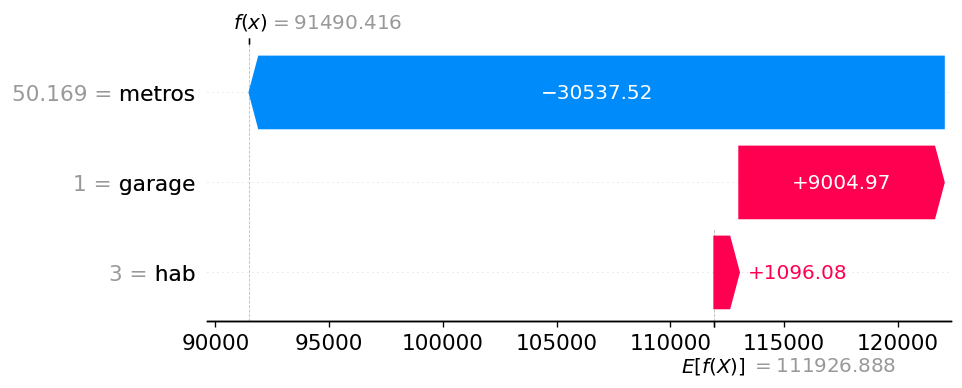

In [7]:
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

shap.plots.waterfall(shap_values[0], show=True)

### 6.2 Force Plot — Vista compacta

Misma información que el waterfall pero en horizontal. Útil para comparar varias observaciones a la vez.

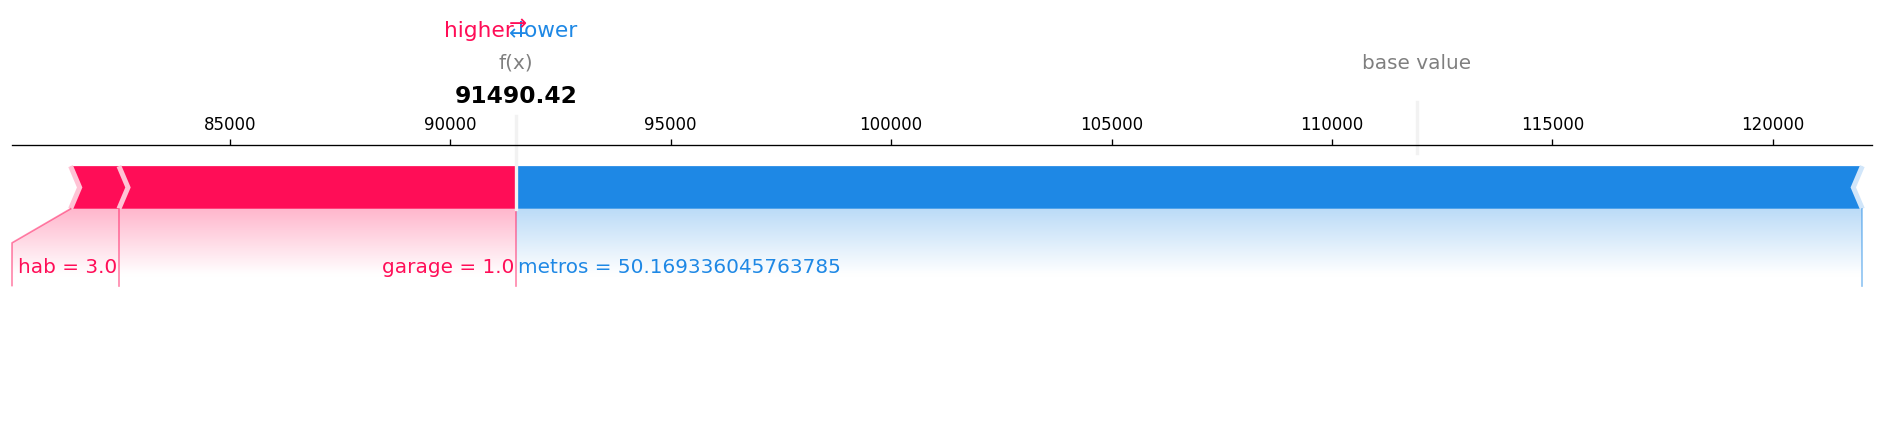

In [8]:
shap.plots.force(
    shap_values.base_values[0],
    shap_values.values[0],
    X_test.iloc[0],
    matplotlib=True
)

### 6.3 Beeswarm — Todo el test set

Muestra la distribución de SHAP values para **todas las observaciones** a la vez.

- Cada punto = una observación
- **Eje X:** valor de $\phi_j$ (derecha = sube predicción, izquierda = baja)
- **Color:** valor de la feature (rojo = alto, azul = bajo)
- **Orden vertical:** importancia global = promedio de $|\phi_j|$

💡 *En el modelo lineal el patrón es perfectamente monótono: valores altos de `metros` siempre tienen $\phi > 0$.*

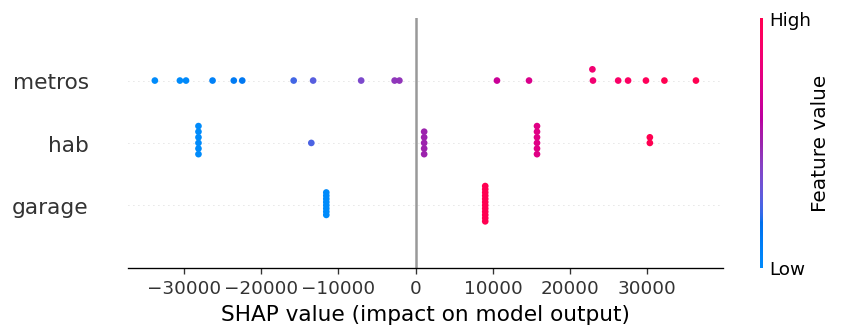

In [9]:
shap.plots.beeswarm(shap_values, show=True)

### 6.4 Bar Plot — Importancia global

Resume la importancia de cada feature como $\text{mean}(|\phi_j|)$ sobre todo el dataset.

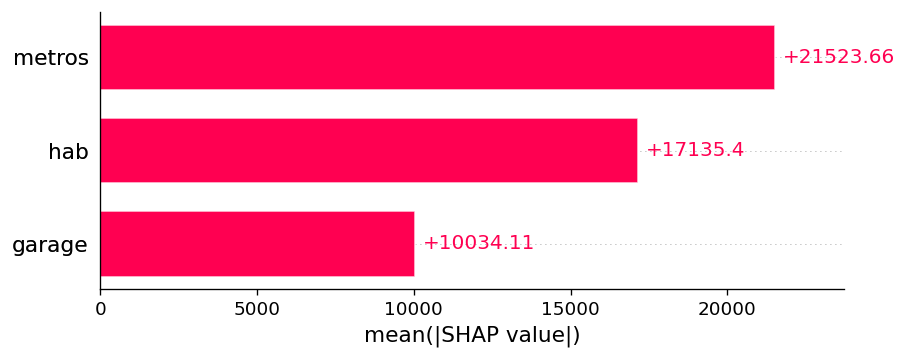

In [10]:
shap.plots.bar(shap_values, show=True)

---

## Resumen

| Concepto | Descripción |
|----------|-------------|
| **SHAP value** $\phi_j$ | Contribución de la feature $j$ a la predicción de **una** observación |
| **Baseline** $E[f(x)]$ | Predicción promedio del modelo sobre el train set |
| **Eficiencia** | $\hat{y} = E[f(x)] + \sum_j \phi_j$ siempre se cumple |
| **Cálculo** | Promedio de contribuciones marginales sobre todos los órdenes |
| **Lineal (fórmula cerrada)** | $\phi_j = \beta_j \cdot (x_j - \bar{x}_j)$ |
| **Número en la barra** | Valor de $\phi_j$: cuánto sube o baja la predicción esa feature |
| **Waterfall** | Camino desde el baseline hasta $\hat{y}$, barra por barra |
| **Beeswarm** | Distribución de $\phi_j$ para todas las observaciones |

---

## 🏋️ Ejercicios Propuestos

1. Calcular manualmente los Shapley values del juego de vendedores verificando **cada orden** para el jugador B.

2. Agregar una 4ª feature `antigüedad` al dataset. ¿Cómo cambia el beeswarm? ¿Qué feature queda con menor SHAP global?

3. Elegir 3 observaciones del test set con predicciones muy distintas (baja, media, alta). Comparar sus waterfall plots. ¿Qué feature domina en cada caso?

4. Verificar la propiedad de eficiencia para 5 observaciones al azar: comprobar que `baseline + Σφ = ŷ`.

---

## 📚 Referencias

- Lundberg & Lee (2017). *A Unified Approach to Interpreting Model Predictions*. NeurIPS.
- Shapley, L.S. (1953). *A value for n-person games*. Contributions to the Theory of Games.
- Molnar, C. (2022). *Interpretable Machine Learning*. https://christophm.github.io/interpretable-ml-book/

1. Calcular manualmente los Shapley values del juego de vendedores verificando **cada orden** para el jugador B.

In [11]:

# Ejercicio 1 — Shapley value de B verificando cada orden manualmente
# Con 3 jugadores hay 3! = 6 órdenes posibles.
# Para cada orden calculamos la contribución marginal de B:
#   contribución = v(S_antes_de_B ∪ {B}) − v(S_antes_de_B)

from itertools import permutations
from math import factorial

jugador_objetivo = 'B'
# print(list(permutations(jugadores)))

print("=" * 72)
print(f"  Cálculo manual del Shapley value del vendedor {jugador_objetivo}")
print("=" * 72)
print(f"  {'Orden':15s}  {'S (antes de B)':18s}  {'S ∪ B':15s}  {'v(S)':>8s}  {'v(S∪B)':>8s}  {'Contrib.':>10s}")
print("-" * 72)


contribuciones = []
for orden in permutations(jugadores):
    idx_b   = orden.index(jugador_objetivo)
    s_antes = frozenset(orden[:idx_b])   # jugadores que llegan antes que B
    s_con_b = s_antes | frozenset([jugador_objetivo])

    v_antes  = ganancia(s_antes)
    v_con_b  = ganancia(s_con_b)
    contrib  = v_con_b - v_antes
    contribuciones.append(contrib)
    
    #print(f"contrib {contrib}")

    s_str     = '{' + ', '.join(sorted(s_antes)) + '}' if s_antes else '{}'
    s_con_str = '{' + ', '.join(sorted(s_con_b)) + '}'
    orden_str = ' → '.join(orden)
    signo     = '+' if contrib >= 0 else ''
    print(f"  {orden_str:15s}  {s_str:18s}  {s_con_str:15s}  {v_antes:>8.0f}  {v_con_b:>8.0f}  {signo}{contrib:>9.0f}")

print("-" * 72)
suma  = sum(contribuciones)
n     = factorial(len(jugadores))
phi_b = suma / n
print(f"  Suma de contribuciones = {suma:.0f}")
print(f"  Nº de órdenes          = {n}")
print(f"  Shapley value de B     = {suma:.0f} / {n} = {phi_b:.2f}")
print("=" * 72)

# Verificación con la función shapley_value() definida en la clase
phi_verificacion = shapley_value(jugador_objetivo, jugadores, ganancia)
print(f"\n  ✅ Verificación con shapley_value(): φ_B = ${phi_verificacion:.2f}")
print(f"     Coincide con el cálculo manual   : {'✓' if abs(phi_b - phi_verificacion) < 1e-9 else '✗'}")

# Tabla resumen de los 3 jugadores
print("\n" + "=" * 40)
print("  Shapley values — resumen final")
print("=" * 40)
for j in jugadores:
    phi = shapley_value(j, jugadores, ganancia)
    print(f"  Vendedor {j}: ${phi:.2f}")
print("-" * 40)
print(f"  Total repartido: ${sum(shapley_value(j, jugadores, ganancia) for j in jugadores):.2f}  (debe ser $900)")
print("=" * 40)


  Cálculo manual del Shapley value del vendedor B
  Orden            S (antes de B)      S ∪ B                v(S)    v(S∪B)    Contrib.
------------------------------------------------------------------------
  A → B → C        {A}                 {A, B}                300       600  +      300
  A → C → B        {A, C}              {A, B, C}             500       900  +      400
  B → A → C        {}                  {B}                     0       200  +      200
  B → C → A        {}                  {B}                     0       200  +      200
  C → A → B        {A, C}              {A, B, C}             500       900  +      400
  C → B → A        {C}                 {B, C}                100       400  +      300
------------------------------------------------------------------------
  Suma de contribuciones = 1800
  Nº de órdenes          = 6
  Shapley value de B     = 1800 / 6 = 300.00

  ✅ Verificación con shapley_value(): φ_B = $300.00
     Coincide con el cálculo manual 

2. Agregar una 4ª feature `antigüedad` al dataset. ¿Cómo cambia el beeswarm? ¿Qué feature queda con menor SHAP global?

  Coeficientes del modelo con 4 features
  metros      : $     +530  ▲
  hab         : $  +15,181  ▲
  garage      : $  +22,494  ▲
  antiguedad  : $     -706  ▼
  R² en test    : 0.9100

Beeswarm con 4 features:


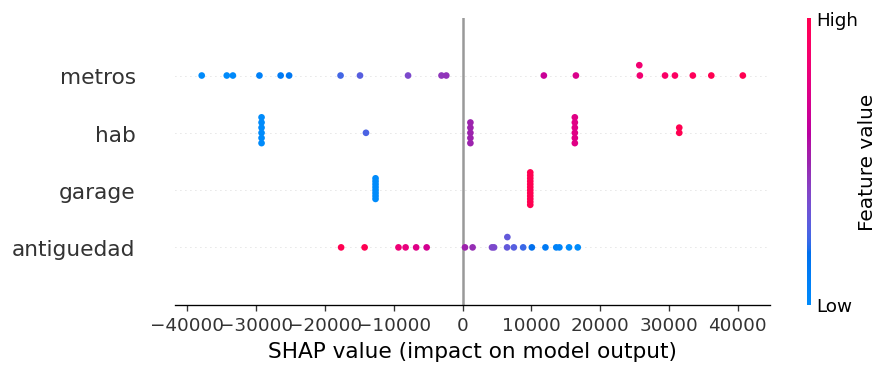


Importancia global mean(|φ|):


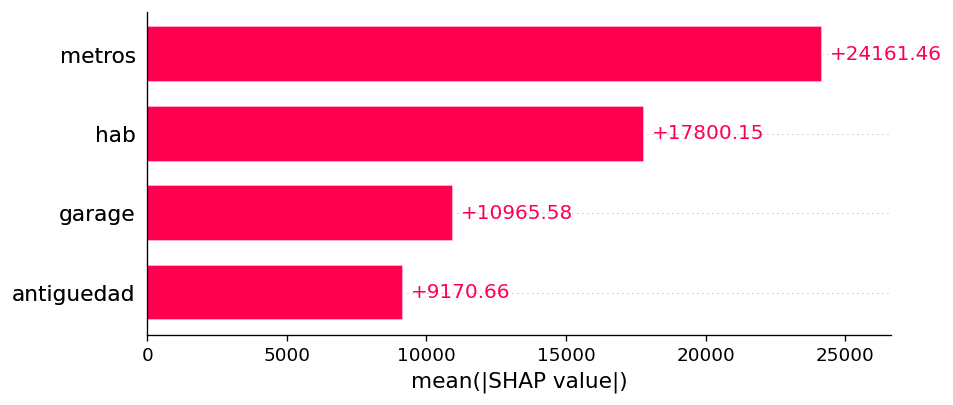


  mean(|φ|) por feature — ranking global
  metros      : $   24,161  ████████████
  hab         : $   17,800  ████████
  garage      : $   10,966  █████
  antiguedad  : $    9,171  ████
---------------------------------------------
  → Menor SHAP global: 'antiguedad' ($9,171)


In [12]:

# Ejercicio 2 — Agregar feature `antigüedad` y analizar el impacto en beeswarm

# ── 1. Nuevo dataset con 4 features ───────────────────────────────
np.random.seed(42)
n = 100

metros2    = np.random.uniform(40, 200, n)
hab2       = np.random.randint(1, 6, n).astype(float)
garage2    = np.random.randint(0, 2, n).astype(float)
antiguedad = np.random.uniform(0, 50, n)   # años (0 = nueva, 50 = muy vieja)

# El precio cae $600 por cada año de antigüedad
precio2 = (
      500 * metros2
  + 15000 * hab2
  + 20000 * garage2
  +  -600 * antiguedad
  + np.random.normal(0, 8000, n)
)

df2 = pd.DataFrame({
    'metros'     : metros2,
    'hab'        : hab2,
    'garage'     : garage2,
    'antiguedad' : antiguedad,
    'precio'     : precio2,
})

# ── 2. Entrenar modelo con las 4 features ─────────────────────────
X2 = df2[['metros', 'hab', 'garage', 'antiguedad']]
y2 = df2['precio']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

modelo2 = LinearRegression()
modelo2.fit(X2_train, y2_train)

print("=" * 50)
print("  Coeficientes del modelo con 4 features")
print("=" * 50)
for feat, coef in zip(X2.columns, modelo2.coef_):
    signo = "▲" if coef > 0 else "▼"
    print(f"  {feat:12s}: ${coef:>+9,.0f}  {signo}")
print(f"  R² en test    : {modelo2.score(X2_test, y2_test):.4f}")
print("=" * 50)

# ── 3. SHAP values con LinearExplainer ────────────────────────────
explainer2   = shap.LinearExplainer(modelo2, X2_train,
                                     feature_perturbation='interventional')
shap_values2 = explainer2(X2_test)

# ── 4. Beeswarm ───────────────────────────────────────────────────
print("\nBeeswarm con 4 features:")
shap.plots.beeswarm(shap_values2, show=True)

# ── 5. Bar plot — importancia global ──────────────────────────────
print("\nImportancia global mean(|φ|):")
shap.plots.bar(shap_values2, show=True)

# ── 6. Tabla numérica para responder la pregunta ──────────────────
mean_abs = {
    feat: float(np.mean(np.abs(shap_values2.values[:, i])))
    for i, feat in enumerate(X2.columns)
}

print("\n" + "=" * 45)
print("  mean(|φ|) por feature — ranking global")
print("=" * 45)
for feat, val in sorted(mean_abs.items(), key=lambda x: x[1], reverse=True):
    barra = "█" * max(1, int(val / 2000))
    print(f"  {feat:12s}: ${val:>9,.0f}  {barra}")
print("-" * 45)
menor = min(mean_abs, key=mean_abs.get)
print(f"  → Menor SHAP global: '{menor}' (${mean_abs[menor]:,.0f})")
print("=" * 45)


3. Elegir 3 observaciones del test set con predicciones muy distintas (baja, media, alta). Comparar sus waterfall plots. ¿Qué feature domina en cada caso?

  Observaciones seleccionadas para comparar waterfalls
  Caso              idx             ŷ
------------------------------------------------------------
  Precio BAJO         9  $     52,202
  Precio MEDIO        1  $     93,171
  Precio ALTO        13  $    163,529

Características de cada observación:
    metros  hab  garage  antiguedad  precio_pred
0     99.9  1.0     0.0        17.5      52201.5
53   183.2  1.0     0.0        21.9      93171.2
33   191.8  5.0     0.0        14.8     163528.8

── Waterfall: Precio BAJO (ŷ = $52,202) ──


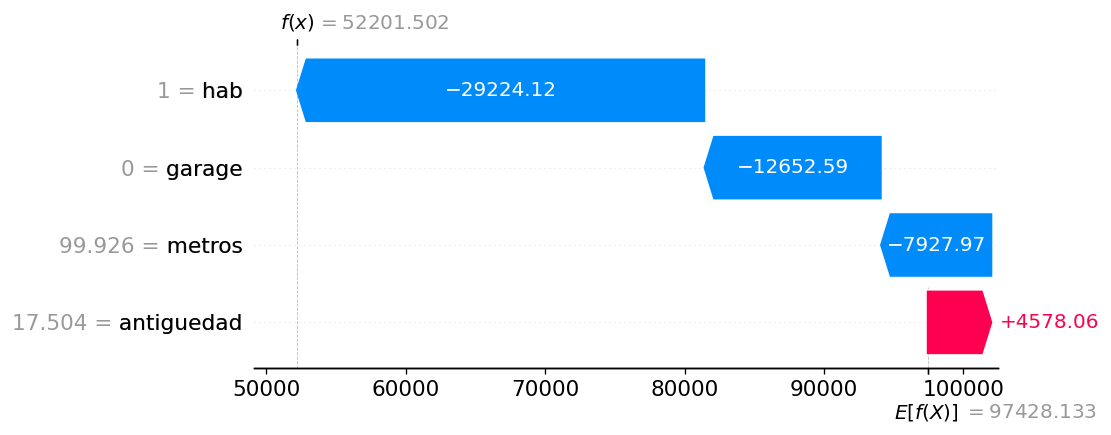


── Waterfall: Precio MEDIO (ŷ = $93,171) ──


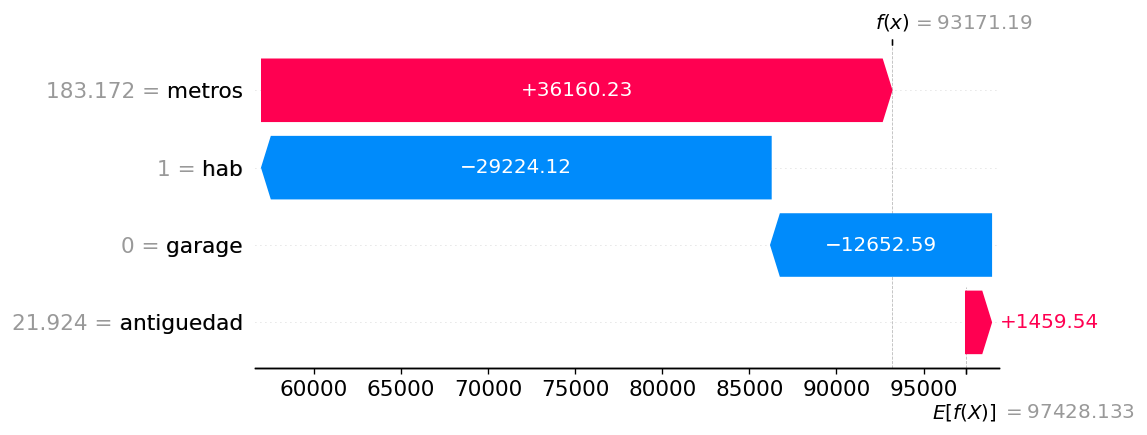


── Waterfall: Precio ALTO (ŷ = $163,529) ──


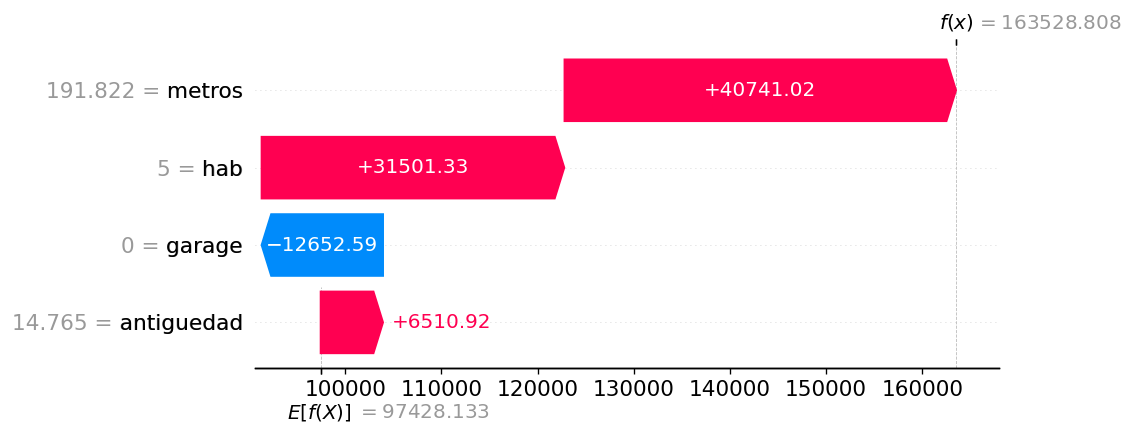


  Feature con mayor |φ| en cada observación
  Precio BAJO      → 'hab' (φ = $-29,224)
  Precio MEDIO     → 'metros' (φ = $+36,160)
  Precio ALTO      → 'metros' (φ = $+40,741)

Interpretación:
  - En la predicción BAJA:  pocos metros y/o alta antigüedad empujan
    el precio muy por debajo del baseline.
  - En la predicción MEDIA: las features se compensan entre sí; ninguna
    produce una desviación grande respecto al promedio.
  - En la predicción ALTA:  muchos metros y/o tener garage suman
    contribuciones positivas que alejan el precio hacia arriba.

  En el modelo lineal, 'metros' suele dominar por su amplio rango
  (40–200 m²) multiplicado por β ≈ 500, generando los mayores |φ|.



In [13]:

# Ejercicio 3 — 3 waterfall plots: predicción baja, media y alta

# ── 1. Predicciones sobre el test set (usamos modelo2 de 4 features) ──
y2_pred = modelo2.predict(X2_test)

# Índices de la observación con precio más bajo, más cercano a la mediana y más alto
idx_low  = int(np.argmin(y2_pred))
idx_high = int(np.argmax(y2_pred))
mediana  = np.median(y2_pred)
idx_mid  = int(np.argmin(np.abs(y2_pred - mediana)))

casos = {
    'Precio BAJO'   : idx_low,
    'Precio MEDIO'  : idx_mid,
    'Precio ALTO'   : idx_high,
}

print("=" * 60)
print("  Observaciones seleccionadas para comparar waterfalls")
print("=" * 60)
print(f"  {'Caso':15s}  {'idx':>4s}  {'ŷ':>12s}")
print("-" * 60)
for nombre, idx in casos.items():
    print(f"  {nombre:15s}  {idx:>4d}  ${y2_pred[idx]:>11,.0f}")
print("=" * 60)

print("\nCaracterísticas de cada observación:")
print(X2_test.iloc[[idx_low, idx_mid, idx_high]].assign(
    precio_pred=y2_pred[[idx_low, idx_mid, idx_high]]
).round(1).to_string())

# ── 2. Waterfall para cada caso ────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 120

for nombre, idx in casos.items():
    print(f"\n── Waterfall: {nombre} (ŷ = ${y2_pred[idx]:,.0f}) ──")
    shap.plots.waterfall(shap_values2[idx], show=True)

# ── 3. Análisis: feature dominante en cada caso ────────────────────
print("\n" + "=" * 60)
print("  Feature con mayor |φ| en cada observación")
print("=" * 60)
features = list(X2.columns)
for nombre, idx in casos.items():
    vals     = shap_values2.values[idx]
    dom_feat = features[int(np.argmax(np.abs(vals)))]
    dom_phi  = vals[int(np.argmax(np.abs(vals)))]
    print(f"  {nombre:15s}  → '{dom_feat}' (φ = ${dom_phi:+,.0f})")
print("=" * 60)
print("""
Interpretación:
  - En la predicción BAJA:  pocos metros y/o alta antigüedad empujan
    el precio muy por debajo del baseline.
  - En la predicción MEDIA: las features se compensan entre sí; ninguna
    produce una desviación grande respecto al promedio.
  - En la predicción ALTA:  muchos metros y/o tener garage suman
    contribuciones positivas que alejan el precio hacia arriba.

  En el modelo lineal, 'metros' suele dominar por su amplio rango
  (40–200 m²) multiplicado por β ≈ 500, generando los mayores |φ|.
""")


4. Verificar la propiedad de eficiencia para 5 observaciones al azar: comprobar que `baseline + Σφ = ŷ`.

In [16]:

# Ejercicio 4 — Verificar la propiedad de eficiencia para 5 observaciones al azar
#
# Propiedad de eficiencia (axioma de Shapley):
#   baseline + Σ φⱼ = ŷ   para toda observación
#
# Usando modelo2 (4 features) y shap_values2

np.random.seed(7)
indices_azar = np.random.choice(len(X2_test), size=5, replace=False)

baseline2 = shap_values2.base_values[0]   # igual para todas las obs en LinearExplainer

print("=" * 78)
print("  Verificación de la propiedad de eficiencia:  E[f(x)] + Σφⱼ = ŷ")
print("=" * 78)
print(f"  Baseline E[f(x)] = ${baseline2:,.2f}")
print()
print(f"  {'idx':>4s}  {'ŷ (modelo)':>14s}  {'baseline':>14s}  {'Σ(φ)':>14s}  "
      f"{'base+Σφ':>14s}  {'Δ (error)':>12s}  {'✓'}") 
print("-" * 78)

tolerancia = 1e-6
todas_ok = True

for i in indices_azar:
    y_pred_i      = float(modelo2.predict(X2_test.iloc[[i]])[0])
    suma_phi      = float(shap_values2.values[i].sum())
    reconstruido  = baseline2 + suma_phi
    error         = abs(reconstruido - y_pred_i)
    ok            = error < tolerancia
    todas_ok     &= ok
    marca         = "✓" if ok else "✗"
    print(f"  {i:>4d}  ${y_pred_i:>13,.2f}  ${baseline2:>13,.2f}  ${suma_phi:>+13,.2f}  "
          f"${reconstruido:>13,.2f}  {error:>12.2e}  {marca}")

print("-" * 78)
print(f"\n  Resultado: {'✅ Propiedad verificada en las 5 observaciones' if todas_ok else '❌ Alguna observación falló'}")
print()

# ── Desglose detallado de una observación ─────────────────────────
idx_ejemplo = int(indices_azar[0])
print("=" * 60)
print(f"  Desglose completo — observación idx={idx_ejemplo}")
print("=" * 60)
print(f"  {'Feature':12s}  {'valor x':>10s}  {'φⱼ':>12s}")
print("-" * 60)
acum = baseline2
print(f"  {'[baseline]':12s}  {'':>10s}  ${baseline2:>11,.2f}")
for j, feat in enumerate(X2.columns):
    phi_j = shap_values2.values[idx_ejemplo][j]
    acum += phi_j
    print(f"  {feat:12s}  {X2_test.iloc[idx_ejemplo][feat]:>10.2f}  ${phi_j:>+11,.2f}")
print("-" * 60)
y_final = float(modelo2.predict(X2_test.iloc[[idx_ejemplo]])[0])
print(f"  {'[ŷ]':12s}  {'':>10s}  ${acum:>11,.2f}  ← base + Σφ")
print(f"  {'modelo.predict':12s}  {'':>10s}  ${y_final:>11,.2f}  ← ŷ directo")
print(f"  {'diferencia':12s}  {'':>10s}   {abs(acum - y_final):>11.2e}")
print("=" * 60)


  Verificación de la propiedad de eficiencia:  E[f(x)] + Σφⱼ = ŷ
  Baseline E[f(x)] = $97,428.13

   idx      ŷ (modelo)        baseline            Σ(φ)         base+Σφ     Δ (error)  ✓
------------------------------------------------------------------------------
     1  $    93,171.19  $    97,428.13  $    -4,256.94  $    93,171.19      1.46e-11  ✓
    17  $    68,002.39  $    97,428.13  $   -29,425.75  $    68,002.39      1.46e-11  ✓
     2  $   159,432.75  $    97,428.13  $   +62,004.62  $   159,432.75      0.00e+00  ✓
     5  $    82,144.71  $    97,428.13  $   -15,283.42  $    82,144.71      0.00e+00  ✓
    11  $    90,981.76  $    97,428.13  $    -6,446.37  $    90,981.76      1.46e-11  ✓
------------------------------------------------------------------------------

  Resultado: ✅ Propiedad verificada en las 5 observaciones

  Desglose completo — observación idx=1
  Feature          valor x            φⱼ
------------------------------------------------------------
  [baseline] 